# 🎯 03 — YOLOv8 Object Detection
**Border Surveillance AI · GTU Internship 2026**

Training data sources used in this notebook:

| Source | Classes | Used for |
|--------|---------|----------|
| Roboflow (custom annotated) | person, vehicle, weapon, suspicious_object | Primary fine-tuning |
| xView chips (processed) | vehicle | Aerial vehicle detection |
| DOTA chips (processed) | vehicle, suspicious_object | Aerial detection |
| COCO pretrained weights | 80 classes | Starting point (yolov8n.pt) |

---

In [1]:
import sys, os, shutil
sys.path.insert(0, '../src')

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import yaml
from pathlib import Path

from ultralytics import YOLO
from detect_objects import ObjectDetector

# ── Paths ────────────────────────────────────────────────────────────────────
PROCESSED_DIR  = '../data/processed'
MODELS_DIR     = '../models'
RESULTS_DIR    = '../results'

os.makedirs(MODELS_DIR,                    exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/metrics',      exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/screenshots',  exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/charts',       exist_ok=True)

print('YOLOv8 ready ✓')

YOLOv8 ready ✓


---
## STEP 1 — Test Pre-trained YOLOv8n on Sample Frames

Testing on 5 frames from multiple datasets...

0: 640x640 1 person, 84.6ms
1: 640x640 (no detections), 84.6ms
2: 640x640 1 person, 84.6ms
3: 640x640 1 truck, 84.6ms
4: 640x640 (no detections), 84.6ms
Speed: 2.8ms preprocess, 84.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


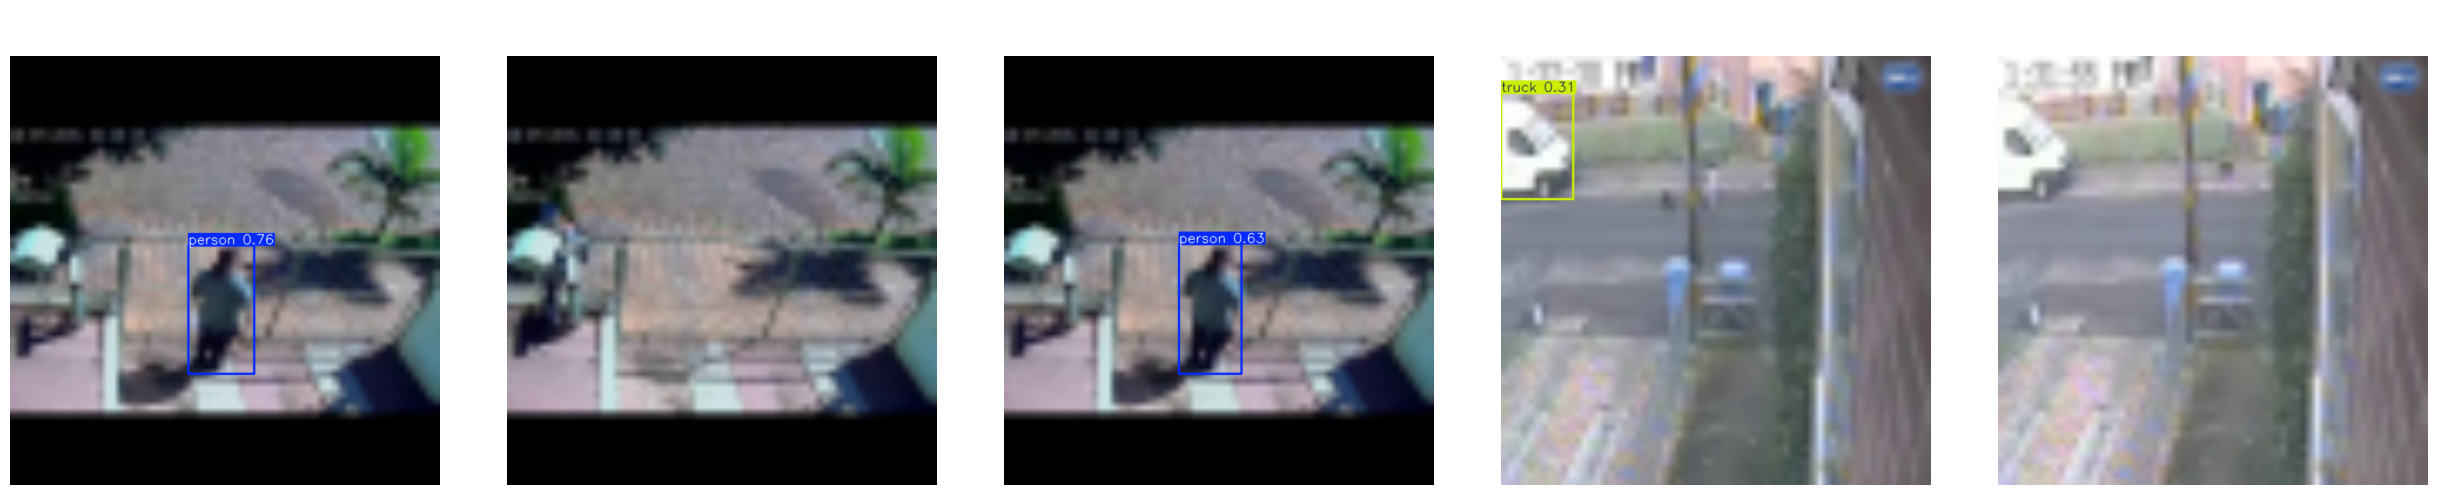

Saved → results/screenshots/pretrained_detections.png


In [2]:
model = YOLO('yolov8n.pt')   # downloads ~6 MB if not present

sample_frames = (glob.glob(f'{PROCESSED_DIR}/test/**/*.jpg', recursive=True) +
                 glob.glob(f'{PROCESSED_DIR}/xview_chips/images/*.jpg') +
                 glob.glob(f'{PROCESSED_DIR}/dota_yolo/images/*.jpg'))[:5]

if not sample_frames:
    print('[WARN] No processed frames found. Run 02_Preprocessing.ipynb first.')
else:
    print(f'Testing on {len(sample_frames)} frames from multiple datasets...')
    results = model(sample_frames, conf=0.30)

    fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 5))
    if len(results) == 1: axes = [axes]

    for ax, r in zip(axes, results):
        annotated = r.plot()
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f'{len(r.boxes)} detections\n{Path(r.path).parent.name}',
                     color='white', fontsize=9)
        ax.axis('off')

    plt.suptitle('YOLOv8n Pre-trained — Detection on All Dataset Types',
                 color='white', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/screenshots/pretrained_detections.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()
    print('Saved → results/screenshots/pretrained_detections.png')

---
## STEP 2 — Build Combined YOLO Dataset (Roboflow + xView + DOTA)

In [3]:
# ── Dataset from CVAT annotation (replaces Roboflow completely) ───────────────
# Make sure you have already run:
#   1. python src/pick_frames.py
#   2. Annotated in CVAT → exported as "YOLO 1.1" → unzipped to data/to_annotate/
#   3. python src/prepare_annotated_dataset.py

import subprocess, sys, os

CVAT_DATASET_DIR = '../data/processed/yolo_annotated'
DATA_YAML        = '../data/border_data.yaml'

# Check if dataset is already prepared
train_images = os.path.join(CVAT_DATASET_DIR, 'train', 'images')
n_train      = len(os.listdir(train_images)) if os.path.exists(train_images) else 0

if n_train > 0:
    print(f'✅ CVAT dataset ready — {n_train} training images found')
    print(f'   Location : {CVAT_DATASET_DIR}')
    print(f'   YAML     : {DATA_YAML}')

else:
    print('[INFO] Dataset not prepared yet. Running prepare_annotated_dataset.py...')
    result = subprocess.run(
        [sys.executable, '../src/prepare_annotated_dataset.py'],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print('ERROR:', result.stderr)
    else:
        print('✅ Dataset prepared successfully!')

# Verify border_data.yaml exists
if os.path.exists(DATA_YAML):
    print(f'\nborder_data.yaml contents:')
    with open(DATA_YAML) as f:
        print(f.read())
else:
    print(f'[ERROR] {DATA_YAML} not found — run prepare_annotated_dataset.py first')

✅ CVAT dataset ready — 336 training images found
   Location : ../data/processed/yolo_annotated
   YAML     : ../data/border_data.yaml

border_data.yaml contents:
path: F:\b\Border-Surveillance-Project\data\processed\yolo_annotated
train: train/images
val: val/images
test: test/images
nc: 4
names:
  0: person
  1: vehicle
  2: weapon
  3: suspicious_object



In [4]:
# ── Build combined dataset by merging all available sources ───────────────────

COMBINED_DIR = '../data/processed/yolo_annotated'

for split in ['train', 'val', 'test']:
    os.makedirs(f'{COMBINED_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{COMBINED_DIR}/{split}/labels', exist_ok=True)

def copy_yolo_data(src_img_dir, src_lbl_dir, dst_split, tag=''):
    """Copy images and labels into the combined dataset."""
    images = glob.glob(f'{src_img_dir}/*.jpg') + glob.glob(f'{src_img_dir}/*.png')
    copied = 0
    for img_path in images:
        stem      = Path(img_path).stem
        lbl_path  = os.path.join(src_lbl_dir, f'{stem}.txt')
        if not os.path.exists(lbl_path):
            continue
        dst_img = os.path.join(COMBINED_DIR, dst_split, 'images', f'{tag}{stem}.jpg')
        dst_lbl = os.path.join(COMBINED_DIR, dst_split, 'labels', f'{tag}{stem}.txt')
        shutil.copy2(img_path, dst_img)
        shutil.copy2(lbl_path, dst_lbl)
        copied += 1
    return copied

total_combined = {'train': 0, 'val': 0, 'test': 0}

# ── 1. Add CVAT annotated data ────────────────────────────────────────────────
cvat_dir = '../data/processed/yolo_annotated'
if os.path.exists(cvat_dir):
    for split in ['train', 'val', 'test']:
        src_img = os.path.join(cvat_dir, split, 'images')
        src_lbl = os.path.join(cvat_dir, split, 'labels')
        if os.path.exists(src_img):
            n = copy_yolo_data(src_img, src_lbl, split, tag='cvat_')
            total_combined[split] += n
            print(f'  CVAT {split}: {n} images')
else:
    print('[SKIP] CVAT dataset not found — run prepare_annotated_dataset.py first')

# ── 2. Add xView chips ────────────────────────────────────────────────────────
xview_img_dir = f'{PROCESSED_DIR}/xview_chips/images'
xview_lbl_dir = f'{PROCESSED_DIR}/xview_chips/labels'
if os.path.exists(xview_img_dir):
    all_xview = glob.glob(f'{xview_img_dir}/*.jpg')
    import random; random.seed(42); random.shuffle(all_xview)
    n_train = int(0.70 * len(all_xview))
    n_val   = int(0.15 * len(all_xview))
    for i, img_path in enumerate(all_xview):
        split = 'train' if i < n_train else ('val' if i < n_train+n_val else 'test')
        stem     = Path(img_path).stem
        lbl_path = os.path.join(xview_lbl_dir, f'{stem}.txt')
        if os.path.exists(lbl_path):
            shutil.copy2(img_path, f'{COMBINED_DIR}/{split}/images/xv_{stem}.jpg')
            shutil.copy2(lbl_path, f'{COMBINED_DIR}/{split}/labels/xv_{stem}.txt')
            total_combined[split] += 1
    print(f'  xView: {len(all_xview)} chips added')

# ── 3. Add DOTA chips ─────────────────────────────────────────────────────────
dota_img_dir = f'{PROCESSED_DIR}/dota_yolo/images'
dota_lbl_dir = f'{PROCESSED_DIR}/dota_yolo/labels'
if os.path.exists(dota_img_dir):
    all_dota = glob.glob(f'{dota_img_dir}/*.jpg')
    random.shuffle(all_dota)
    n_train = int(0.70 * len(all_dota))
    n_val   = int(0.15 * len(all_dota))
    for i, img_path in enumerate(all_dota):
        split    = 'train' if i < n_train else ('val' if i < n_train+n_val else 'test')
        stem     = Path(img_path).stem
        lbl_path = os.path.join(dota_lbl_dir, f'{stem}.txt')
        if os.path.exists(lbl_path):
            shutil.copy2(img_path, f'{COMBINED_DIR}/{split}/images/dt_{stem}.jpg')
            shutil.copy2(lbl_path, f'{COMBINED_DIR}/{split}/labels/dt_{stem}.txt')
            total_combined[split] += 1
    print(f'  DOTA  : {len(all_dota)} chips added')

print('\n── Combined Dataset ─────────────────────')
for split, n in total_combined.items():
    print(f'  {split:<8}: {n:>5} images')
print(f'  TOTAL   : {sum(total_combined.values())}')

  CVAT train: 336 images
  CVAT val: 67 images
  CVAT test: 74 images
  xView: 0 chips added
  DOTA  : 87 chips added

── Combined Dataset ─────────────────────
  train   :   396 images
  val     :    80 images
  test    :    88 images
  TOTAL   : 564


In [5]:
# ── Update border_data.yaml to point to combined dataset ─────────────────────
# SKIPPED — border_data.yaml already points to correct path
print("Cell 7 skipped — border_data.yaml already correct")
yolo_config = {
    'path':  os.path.abspath(COMBINED_DIR),
    'train': 'train/images',
    'val':   'val/images',
    'test':  'test/images',
    'nc':    4,
    'names': {0: 'person', 1: 'vehicle', 2: 'weapon', 3: 'suspicious_object'}
}

DATA_YAML = '../data/border_data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False, sort_keys=False)

print(f'border_data.yaml updated → {DATA_YAML}')
with open(DATA_YAML) as f: print(f.read())

Cell 7 skipped — border_data.yaml already correct
border_data.yaml updated → ../data/border_data.yaml
path: F:\b\Border-Surveillance-Project\data\processed\yolo_annotated
train: train/images
val: val/images
test: test/images
nc: 4
names:
  0: person
  1: vehicle
  2: weapon
  3: suspicious_object



---
## STEP 3 — Fine-tune YOLOv8n on Combined Dataset
> **Run this on Google Colab with T4 GPU for faster training (~30-60 min for 50 epochs)**

In [6]:
# ── If running on Colab: upload border_data.yaml and combined dataset first ───
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_YAML = '/content/drive/MyDrive/Border-Surveillance-AI/data/border_data.yaml'

model = YOLO('yolov8n.pt')

train_results = model.train(
    data       = DATA_YAML,
    epochs     = 30,
    imgsz      = 640,
    batch      = 8,           # reduce to 8 if GPU runs out of memory
    name       = 'border_surveillance',
    workers    = 0,               # ← add this line
    patience   = 10,           # early stopping
    save       = True,
    device     = 'cpu',            # GPU; use 'cpu' if no GPU
    optimizer  = 'SGD',
    lr0        = 0.01,
    augment    = True,
    flipud     = 0.3,          # useful for satellite imagery
    mosaic     = 1.0,
)

print('Training complete!')
print(f"Best mAP@50: {train_results.results_dict.get('metrics/mAP50(B)', 'N/A')}")

Ultralytics 8.4.33  Python-3.11.9 torch-2.1.2+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/border_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=border_surveillance21, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patie

In [7]:
MODELS_DIR = '../models'
import glob as g, shutil, os

# Find best model by highest mAP from results.csv
all_results = sorted(g.glob('runs/detect/border_surveillance*/results.csv'))
best_run    = None
best_map    = 0.0

for csv_path in all_results:
    try:
        import pandas as pd
        df  = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        col = 'metrics/mAP50(B)'
        if col in df.columns:
            run_best = df[col].max()
            if run_best > best_map:
                best_map = run_best
                best_run = csv_path.replace('results.csv', 'weights/best.pt')
    except:
        pass

if best_run and os.path.exists(best_run):
    target_pt = f'{MODELS_DIR}/yolov8_border.pt'
    shutil.copy2(best_run, target_pt)
    print(f'Best weights saved → {target_pt}')
    print(f'Copied from        → {best_run}')
    print(f'Best mAP@50        → {best_map:.4f}')
else:
    # fallback to latest
    all_best = sorted(g.glob('runs/detect/border_surveillance*/weights/best.pt'))
    if all_best:
        target_pt = f'{MODELS_DIR}/yolov8_border.pt'
        shutil.copy2(all_best[-1], target_pt)
        print(f'Saved from latest run → {all_best[-1]}')

Best weights saved → ../models/yolov8_border.pt
Copied from        → runs/detect\border_surveillance13\weights/best.pt
Best mAP@50        → 0.6315


---
## STEP 4 — Evaluate on Each Dataset Type Separately

In [8]:
MODELS_DIR  = '../models'
RESULTS_DIR = '../results'
from ultralytics import YOLO
import pandas as pd, os

trained_model = YOLO(f'{MODELS_DIR}/yolov8_border.pt')

print('=== Overall Evaluation (Combined Dataset) ===')
metrics = trained_model.val(
    data  = '../data/border_data.yaml',
    split = 'val',
    conf  = 0.25,
    iou   = 0.45,
)

results_df = pd.DataFrame({
    'Metric': ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Value':  [round(metrics.box.map50, 4), round(metrics.box.map, 4),
               round(metrics.box.mp, 4),    round(metrics.box.mr, 4)],
    'Target': ['>0.88', '>0.60', '>0.85', '>0.85'],
})

print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULTS_DIR}/metrics/yolo_evaluation.csv', index=False)
print(f'\nMetrics saved -> {RESULTS_DIR}/metrics/yolo_evaluation.csv')

=== Overall Evaluation (Combined Dataset) ===
Ultralytics 8.4.33  Python-3.11.9 torch-2.1.2+cpu CPU (11th Gen Intel Core i7-1165G7 @ 2.80GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 742.6240.2 MB/s, size: 146.2 KB)
val: Scanning F:\b\Border-Surveillance-Project\data\processed\yolo_annotated\val\labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.0s/it 11.8s2.6s
                   all         87       2294      0.371      0.313      0.354      0.199
                person          5          5          0          0          0          0
               vehicle         57       2017      0.678      0.528      0.641      0.367
                weapon         20         40          0          0          0          0
     suspicious_object         49        232   

In [9]:
MODELS_DIR    = '../models'
RESULTS_DIR   = '../results'
PROCESSED_DIR = '../data/processed'
import sys
sys.path.insert(0, '../src')
from detect_objects import ObjectDetector
import cv2, numpy as np, glob, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


# ── Detection on sample frames from ALL 3 datasets ───────────────────────────
detector = ObjectDetector(f'{MODELS_DIR}/yolov8_border.pt', confidence=0.25)

# Collect test frames from each source
source_frames = {}

ucf_test   = glob.glob(f'{PROCESSED_DIR}/test/**/*.jpg', recursive=True)[:2]
xview_test = glob.glob(f'{PROCESSED_DIR}/xview_chips/images/*.jpg')[:2]
dota_test  = glob.glob(f'{PROCESSED_DIR}/dota_yolo/images/*.jpg')[:2]

if ucf_test:   source_frames['UCF-Crime'] = ucf_test
if xview_test: source_frames['xView']     = xview_test
if dota_test:  source_frames['DOTA']      = dota_test

if source_frames:
    all_items = [(src, fp) for src, fps in source_frames.items() for fp in fps]
    n_cols = min(3, len(all_items))
    n_rows = (len(all_items) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6*n_cols, 5*n_rows))
    axes = np.array(axes).flatten() if hasattr(axes, '__iter__') else [axes]

    for ax, (src, fp) in zip(axes, all_items):
        frame = cv2.imread(fp)
        dets  = detector.detect_frame(frame)
        ann   = detector.draw_detections(frame, dets)
        ax.imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB))
        ax.set_title(f'[{src}] {len(dets)} detections',
                     color='white', fontsize=9)
        ax.axis('off')

    for ax in axes[len(all_items):]: ax.axis('off')

    plt.suptitle('Fine-tuned YOLOv8 — Detections Across All Datasets',
                 color='white', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/screenshots/multi_dataset_detections.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()
    print('Saved → results/screenshots/multi_dataset_detections.png')
else:
    print('[INFO] No test frames found across any dataset.')

[ObjectDetector] Loaded custom weights: ../models/yolov8_border.pt
Saved → results/screenshots/multi_dataset_detections.png


C:\Users\Bhumi Patel\AppData\Local\Temp\ipykernel_30744\3830275494.py:51: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


## STEP 5 — Plot Training History (Loss + mAP Curves)

In [10]:


all_csvs    = sorted(g.glob('runs/detect/border_surveillance*/results.csv'))
results_csv = all_csvs[-1] if all_csvs else None
if results_csv and os.path.exists(results_csv):
    df_train = pd.read_csv(results_csv)
    df_train.columns = df_train.columns.str.strip()
    print('Training history columns:', list(df_train.columns))

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.patch.set_facecolor('#0A0A0A')
    fig.suptitle('YOLOv8 Training History', color='white', fontsize=14)

    plot_pairs = [
        ('train/box_loss', 'val/box_loss',   'Box Loss',  axes[0,0]),
        ('train/cls_loss', 'val/cls_loss',   'Class Loss',axes[0,1]),
        ('metrics/mAP50(B)', None,           'mAP@50',    axes[1,0]),
        ('metrics/precision(B)', 'metrics/recall(B)', 'Precision/Recall', axes[1,1]),
    ]

    for col1, col2, title, ax in plot_pairs:
        ax.set_facecolor('#111111')
        if col1 in df_train.columns:
            ax.plot(df_train[col1], color='#00D4FF', label=col1.split('/')[1])
        if col2 and col2 in df_train.columns:
            ax.plot(df_train[col2], color='#FF6B35', label=col2.split('/')[1], linestyle='--')
        ax.set_title(title, color='white')
        ax.set_xlabel('Epoch', color='white')
        ax.legend(facecolor='#222', labelcolor='white')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/charts/training_history.png',
                dpi=120, facecolor='#0A0A0A')
    plt.show()
else:
    print('[INFO] Training history not found — run training cell first.')

Training history columns: ['epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


C:\Users\Bhumi Patel\AppData\Local\Temp\ipykernel_30744\2249831092.py:32: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
